In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from tensorflow import keras
%matplotlib inline
import numpy as np


In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# X_train = the actual images (the handwritten number pictures)
# y_train = the answers (what number each image shows)
# X_test = different images to test on
# y_test = the answers for the test images

In [3]:
X_train.shape
# (3 Dimensional Array) 60000 images, 28x28 pixels

(60000, 28, 28)

In [4]:
X_train[2]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,  67, 232,  39,   0,   0,   0,
          0,   0],
       [  

In [5]:
X_train = X_train / 255
X_test = X_test / 255
# values were between 0 and 255
# values are now between 0 and 1
# improves the accuracy of the network
# this makes it easier for the network to learn

In [6]:
X_train[2]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [7]:
y_train.shape

(60000,)

In [8]:
y_train[2]

np.uint8(4)

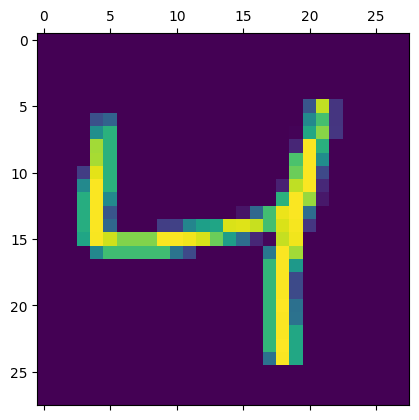

In [9]:
plt.matshow(X_train[2])

In [10]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
# X_train.shape
# (3 Dimensional Array) 60000 images, 28x28 pixels
# doing this will make it a 2 Dimensional Array/shape

# creating a 2D Array/shape is easier for processing, its standard format, 
#  and memory efficient

X_test_flattened = X_test.reshape(len(X_test), 28*28)

X_train_flattened.shape
# produces (60000, 784) which is 2 Dimensional Array/shape

X_test_flattened.shape

(10000, 784)

In [11]:
X_test_flattened[2]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [12]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation='sigmoid')
])
# Dense is a type of layer where every input connects to every output
# 10 is the number of outputs
# input_shape tells the network to expect 784 inputs
# 784 is the number of pixels in each image (expect 784 input values)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# adam is the "learning strategy", how the network will adjust itself when it makes mistakes
# Adam is a smart algorithm that automatically adjusts how big of steps to take when learning

# sparse_categorical_crossentropy measures how wrong its guesses are
# It compares the network's guess with the correct answer and gives a "penalty score"

# accuracy is a measure of how well the network is doing

model.fit(X_train_flattened, y_train, epochs=5)

# fit is where the training happens (the training set)
# y_train is the correct answers
# epochs will look at the entire training set 5 times to learn as much as it can.

Epoch 1/5


C:\Users\Jense\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - accuracy: 0.8109 - loss: 0.7198
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 808us/step - accuracy: 0.9106 - loss: 0.3162
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 815us/step - accuracy: 0.9223 - loss: 0.2796
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - accuracy: 0.9257 - loss: 0.2677
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 813us/step - accuracy: 0.9267 - loss: 0.2630


In [13]:
model.evaluate(X_test_flattened, y_test)
# y_test is the correct answers
# [loss, accuracy]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 751us/step - accuracy: 0.9136 - loss: 0.3026


[0.26778391003608704, 0.9251999855041504]

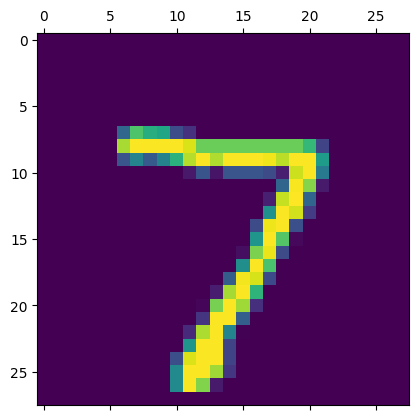

In [14]:
plt.matshow(X_test[0])

In [15]:
# load all predicted values
y_predicted = model.predict(X_test_flattened)

y_predicted[0] # trying to predict the first image which is 7
# outputs array of values 0 to 9

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step


array([2.02862509e-02, 3.74386275e-07, 5.19314744e-02, 9.53271627e-01,
       2.51582172e-03, 1.21035516e-01, 1.16031413e-06, 9.99781966e-01,
       6.93224221e-02, 6.36955380e-01], dtype=float32)

In [16]:
np.argmax(y_predicted[0]) # finds max value in array


np.int64(7)

In [ ]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]
y_predicted_labels[:5] # shows first 5 predicted values

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [27]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [161]:
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)
cm
# cm means confusion matrix

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 962,    0,    1,    2,    0,    5,    7,    2,    1,    0],
       [   0, 1120,    2,    2,    0,    1,    4,    2,    4,    0],
       [   6,   13,  912,   23,    7,    4,   13,    9,   42,    3],
       [   1,    0,   10,  949,    1,   13,    3,    8,   19,    6],
       [   1,    1,    2,    2,  927,    0,   14,    3,   11,   21],
       [   8,    3,    1,   49,   11,  758,   19,    4,   35,    4],
       [   7,    3,    2,    2,    7,   11,  923,    2,    1,    0],
       [   1,   11,   22,   11,    8,    0,    0,  948,    3,   24],
       [   5,   15,    6,   36,    9,   26,   10,   10,  853,    4],
       [  11,    8,    1,   15,   44,    5,    0,   23,   10,  892]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

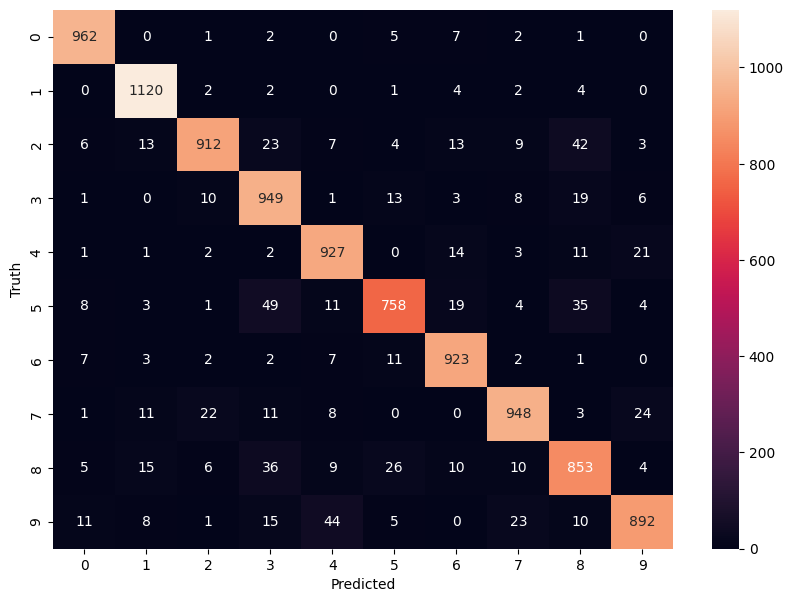

In [162]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

# seaborn library, which is used for making nice-looking charts.
# plt.figure(figsize=(10,7)): Sets the size of the chart to be 10 by 7 inches.

# sn.heatmap(cm, annot=True, fmt='d'): Draws a heatmap (a colored grid) of the confusion matrix cm. 
# The numbers in each box are shown (annot=True), and they are formatted as whole numbers (fmt='d').

# this shows the accuracy of the model
# for example it predicted 0 948 times and it was correct 948 times
# the numnbers that are not in the diagonal are the wrong predictions

In [2]:
model = keras.Sequential([
    keras.layers.Dense(1000, input_shape=(784,), activation='relu'), # this is the hidden layer
    keras.layers.Dense(10, activation='sigmoid')
])

# relu lets positive numbers pass through, but turns negative numbers into zero. 
# This helps the network focus on important signals and learn better.

# More hidden layers/neurons can improve accuracy, but only up to a certain point

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# adam is the "learning strategy", how the network will adjust itself when it makes mistakes
# Adam is a smart algorithm that automatically adjusts how big of steps to take when learning

# sparse_categorical_crossentropy measures how wrong its guesses are
# It compares the network's guess with the correct answer and gives a "penalty score"

# accuracy is a measure of how well the network is doing

model.fit(X_train_flattened, y_train, epochs=10)

# fit is where the training happens (the training set)
# y_train is the correct answers
# epochs will look at the entire training set 5 times to learn as much as it can.


NameError: name 'keras' is not defined

In [164]:
model.evaluate(X_test_flattened, y_test)
# [loss, accuracy]
# adding hidden layer improved accuracy from 92% to 97%

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9789 - loss: 0.0921


[0.0792992040514946, 0.98089998960495]

Text(95.72222222222221, 0.5, 'Truth')

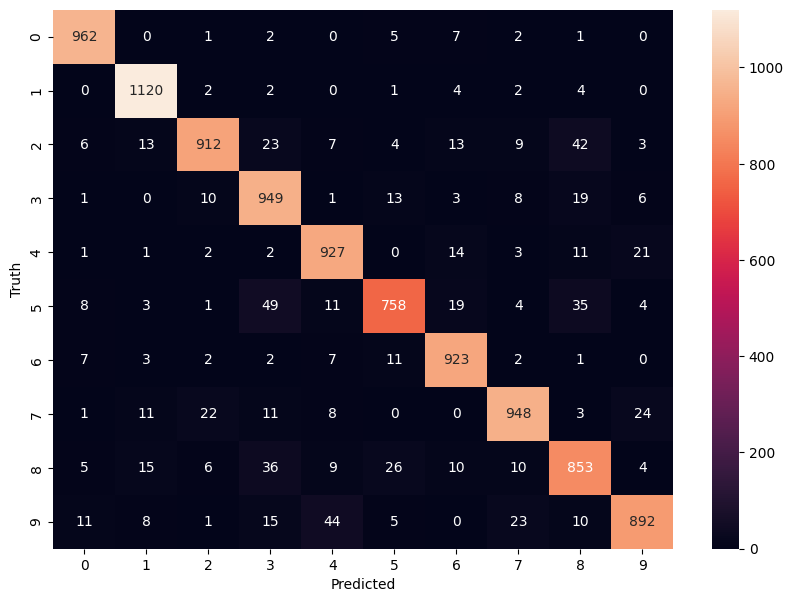

In [165]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [166]:
model.save('model.h5')